Paramètres appris : [ 2.80672595 15.41504183]
Stress estimé : 95.29697692907146


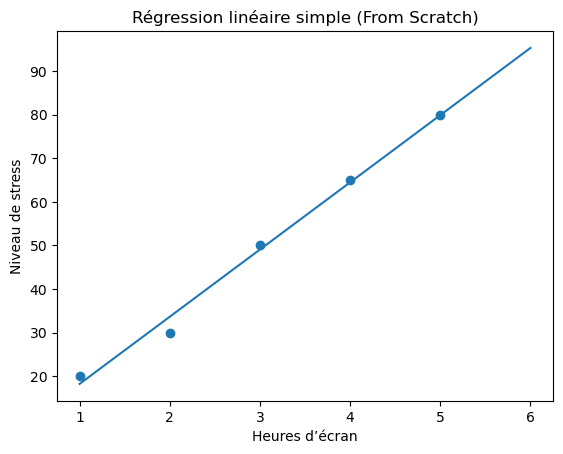

In [31]:
# Régression linéaire simple FROM SCRATCH
# ----------------------------------------

import numpy as np  
# On importe numpy, une bibliothèque essentielle en Python pour manipuler des tableaux (vecteurs, matrices) et effectuer des calculs mathématiques rapidement.

import matplotlib.pyplot as plt  
# Bibliothèque utilisée pour tracer des graphiques (visualisation des données)


# 1. creation du Dataset :
# -------------------------------

X = np.array([1, 2, 3, 4, 5])  
# X représente la variable explicative (input)
# Ici : le nombre d’heures d’écran par jour

y = np.array([20, 30, 50, 65, 80])  
# y représente la variable cible (output)
# Ici : le niveau de stress en pourcentage


# 2. Initialisation :
# -------------------------------

m = len(X)  
# m correspond au nombre total d’exemples dans le dataset
# Ici, on a 5 observations

# Transformation de X en matrice avec colonne de 1
X_b = np.c_[np.ones(m), X]  
# On ajoute une colonne de 1 à X pour intégrer l’intercept (b)
# Cela permet d’écrire le modèle sous forme matricielle :
# y = a*x + b devient y = theta0*1 + theta1*x
# Exemple : si x = 3 → devient [1, 3]

theta = np.zeros(2)  
# Initialisation des paramètres du modèle :
# theta[0] = b (intercept)
# theta[1] = a (coefficient directeur)
# On commence avec des valeurs nulles avant l’apprentissage


# 3. Fonction de coût (MSE)
# -------------------------------

def cost_function(X, y, theta):
    m = len(y)  
    # Nombre d'exemples
    
    predictions = X.dot(theta)  
    # Calcul des valeurs prédites en utilisant le produit matriciel
    
    error = predictions - y  
    # Calcul de l'erreur : différence entre valeurs prédites et réelles
    
    return (1/(2*m)) * np.sum(error**2)  
    # Fonction de coût (Mean Squared Error)
    # On élève les erreurs au carré pour éviter les valeurs négatives
    # Puis on fait la moyenne pour mesurer l'erreur globale du modèle


# 4. Descente de gradient
# -------------------------------

learning_rate = 0.01  
# Taux d’apprentissage : détermine la taille des pas lors de la mise à jour
# Si trop grand → risque de divergence
# Si trop petit → apprentissage lent

iterations = 1000  
# Nombre d’itérations pour améliorer progressivement les paramètres

for i in range(iterations):
    
    gradients = (1/m) * X_b.T.dot(X_b.dot(theta) - y)
    # Calcul du gradient (dérivée de la fonction de coût)
    # Le gradient indique la direction dans laquelle l’erreur augmente
    
    theta = theta - learning_rate * gradients
    # Mise à jour des paramètres :
    # On soustrait le gradient pour minimiser l’erreur
    # C’est le principe de la descente de gradient


# 5. Résultat :
# -------------------------------
print("Paramètres appris :", theta)
# theta[0] = intercept (b)
# theta[1] = coefficient (a)


# 6. Prédiction :
# -------------------------------
nouveau = np.array([1, 6])  
# Nouvelle donnée :
# 1 pour l’intercept, 6 heures d’écran

prediction = nouveau.dot(theta)  
# Produit scalaire pour obtenir la valeur prédite

print("Stress estimé :", prediction)


# 7. Graphique
# -------------------------------
# Génération de plusieurs points pour tracer une droite lisse
X_plot = np.linspace(1, 6, 100)  
# 100 valeurs entre 1 et 6

X_plot_b = np.c_[np.ones(len(X_plot)), X_plot]  
# Ajout de la colonne de 1 pour l’intercept

y_plot = X_plot_b.dot(theta)  
# Calcul des prédictions correspondantes

plt.scatter(X, y)  
# Affichage des données réelles sous forme de points

plt.plot(X_plot, y_plot)  
# Affichage de la droite de régression

plt.xlabel("Heures d’écran")  
# Nom de l’axe X

plt.ylabel("Niveau de stress")  
# Nom de l’axe Y

plt.title("Régression linéaire simple (From Scratch)")  
# Titre du graphique

plt.show()  
# Affichage final du graphique


Stress estimé : 95.50000000000001
Coefficient (a) : 15.500000000000005
Intercept (b) : 2.499999999999986


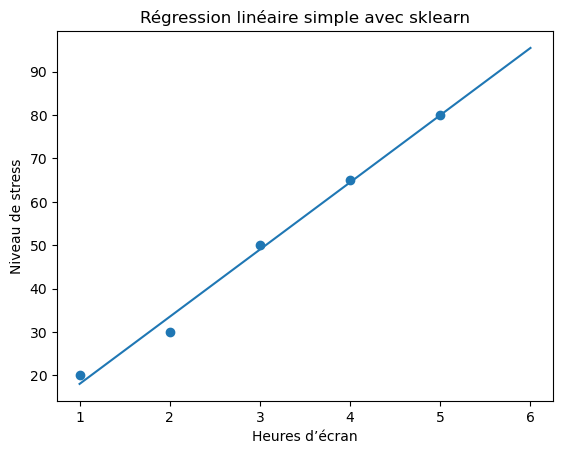

In [4]:
# Régression linéaire simple avec sklearn
# ================================

import numpy as np  
# Importation de numpy, utilisé pour manipuler les données numériques sous forme de tableaux (arrays) et faciliter les calculs.

import matplotlib.pyplot as plt  
# Importation de matplotlib, une bibliothèque utilisée pour afficher des graphiques et visualiser les données.

from sklearn.linear_model import LinearRegression  
# Importation du modèle de régression linéaire de sklearn, qui permet d’apprendre automatiquement une relation linéaire entre X et y.


# 1. Création du dataset
# -------------------------------

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  
# Création de la variable explicative X (heures d’écran).
# reshape(-1,1) transforme X en matrice colonne car sklearn exige un format 2D.

y = np.array([20, 30, 50, 65, 80])  
# Création de la variable cible y (niveau de stress associé à chaque valeur de X).


# 2. Création du modèle
# -------------------------------

model = LinearRegression()  
# Initialisation du modèle de régression linéaire (on crée un objet vide prêt à être entraîné).


# 3. Entraînement
# -------------------------------

model.fit(X, y)  
# Le modèle apprend automatiquement la relation entre X et y.
# Il calcule les paramètres optimaux : la pente (a) et l’intercept (b) en minimisant l’erreur.


# 4. Prédiction
# -------------------------------

prediction = model.predict([[6]])  
# Utilisation du modèle entraîné pour prédire la valeur de y lorsque X = 6 heures.

print("Stress estimé :", prediction[0])  
# Affichage du résultat de la prédiction (on prend [0] car le résultat est sous forme de tableau).


# 5. Paramètres du modèle
# -------------------------------

print("Coefficient (a) :", model.coef_[0])  
# Affiche la pente de la droite, qui représente l’impact de X sur y.

print("Intercept (b) :", model.intercept_)  
# Affiche la valeur de y lorsque X = 0 (point où la droite coupe l’axe Y).


# 6. Graphique
# -------------------------------

X_plot = np.linspace(1, 6, 100).reshape(-1, 1)  
# Génère 100 valeurs régulières entre 1 et 6 pour tracer une droite lisse.

y_plot = model.predict(X_plot)  
# Calcule les valeurs prédites par le modèle pour chaque point de X_plot.

plt.scatter(X, y)  
# Affiche les données réelles sous forme de points (nuage de points).

plt.plot(X_plot, y_plot)  
# Trace la droite de régression qui représente le modèle appris.

plt.xlabel("Heures d’écran")  
# Nom de l’axe horizontal (variable X).

plt.ylabel("Niveau de stress")  
# Nom de l’axe vertical (variable y).

plt.title("Régression linéaire simple avec sklearn")  
# Titre du graphique pour expliquer ce qu’on affiche.

plt.show()  
# Affiche le graphique final à l’écran.

Paramètres appris : [0.76447876 5.8983269  5.13384813 1.74646075]
Fatigue estimée : 56.13642213642214


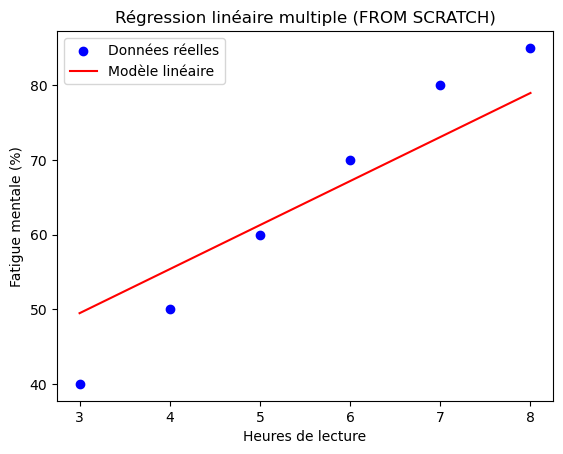

In [13]:
# Régression linéaire multiple FROM SCRATCH
# ----------------------------------------
import numpy as np  
# On importe numpy qui permet de travailler facilement avec les tableaux (vecteurs et matrices) et d’effectuer des calculs mathématiques rapides essentiels pour le machine learning.
import matplotlib.pyplot as plt  
# Importation de matplotlib pour tracer les graphiques


# 1. Dataset
# -------------------------------

X = np.array([
    [3, 2, 7],
    [4, 3, 6],
    [5, 4, 5],
    [6, 5, 4],
    [7, 6, 3],
    [8, 7, 2]
])
# X représente les variables explicatives :
# - colonne 1 : heures de lecture
# - colonne 2 : temps sur réseaux sociaux
# - colonne 3 : heures de sommeil
# Chaque ligne correspond à un étudiant différent

y = np.array([40, 50, 60, 70, 80, 85])  
# y représente la variable cible :
# niveau de fatigue mentale exprimé en pourcentage


# 2. Préparation des données
# -------------------------------

m, n = X.shape  
# m = nombre d’exemples (6 étudiants)
# n = nombre de variables explicatives (3 variables)

X_b = np.c_[np.ones((m, 1)), X]  
# Ajout d’une colonne de 1 pour intégrer l’intercept (b) dans le modèle
# Cela permet d’écrire le modèle sous forme matricielle simplifiée

theta = np.zeros(n + 1)  
# Initialisation des paramètres du modèle :
# theta[0] = intercept (b)
# theta[1..n] = coefficients des variables explicatives


# 3. Fonction de coût
# -------------------------------

def cost_function(X, y, theta):
    m = len(y)  
    # nombre d’exemples dans le dataset

    predictions = X.dot(theta)  
    # calcul des prédictions du modèle en multipliant X par theta

    error = predictions - y  
    # calcul de l’erreur entre les valeurs prédites et les valeurs réelles

    return (1/(2*m)) * np.sum(error**2)  
    # fonction de coût (MSE) :
    # elle mesure la performance du modèle
    # plus elle est petite, meilleur est le modèle


# 4. Descente de gradient
# -------------------------------

learning_rate = 0.01  
# taux d’apprentissage : contrôle la vitesse de mise à jour des paramètres

iterations = 1000  
# nombre d’itérations pour améliorer progressivement le modèle

for i in range(iterations):
    
    gradients = (1/m) * X_b.T.dot(X_b.dot(theta) - y)  
    # calcul du gradient qui indique la direction de l’erreur
    
    theta = theta - learning_rate * gradients  
    # mise à jour des paramètres pour réduire l’erreur
    # on cherche toujours à minimiser la fonction de coût


# 5. Résultats
# -------------------------------

print("Paramètres appris :", theta)  
# affiche l’intercept et les coefficients appris par le modèle


# 6. Prédiction
# -------------------------------

nouveau = np.array([1, 5, 3, 6])  
# nouvelle observation :
# 5h lecture, 3h réseaux sociaux, 6h sommeil

prediction = nouveau.dot(theta)  
# calcul de la fatigue estimée à partir du modèle appris

print("Fatigue estimée :", prediction)

# 7. Graphe (visualisation 2D simplifiée)
# ----------------------------------------
# On ne peut pas représenter directement une régression multiple en 2D
# donc on fixe 2 variables et on fait varier une seule (lecture)

lecture = np.linspace(3, 8, 100)  
# On crée 100 valeurs continues pour la variable "lecture"

social = 4  
# On fixe le temps sur les réseaux sociaux (constante)

sommeil = 6  
# On fixe les heures de sommeil (constante)

# On construit la matrice d’entrée pour la prédiction
X_plot = np.c_[np.ones(100), lecture,
               np.full(100, social),
               np.full(100, sommeil)]
# Chaque ligne devient : [1, lecture, social, sommeil]

# On calcule les prédictions du modèle
y_plot = X_plot.dot(theta)  
# Application directe du modèle appris


# Affichage du graphe
# ================================

plt.scatter(X[:, 0], y, color='blue', label="Données réelles")
# On affiche les vraies données (lecture vs fatigue)

plt.plot(lecture, y_plot, color='red', label="Modèle linéaire")
# On trace la courbe du modèle

plt.xlabel("Heures de lecture")  
# Axe X

plt.ylabel("Fatigue mentale (%)")  
# Axe Y

plt.title("Régression linéaire multiple (FROM SCRATCH)")  
# Titre du graphe

plt.legend()  
# Afficher la légende

plt.show()  
# Afficher le graphique

Fatigue estimée : 53.33333333333334
Coefficients : [ 3.0952381  3.0952381 -3.0952381]
Intercept : 47.14285714285715


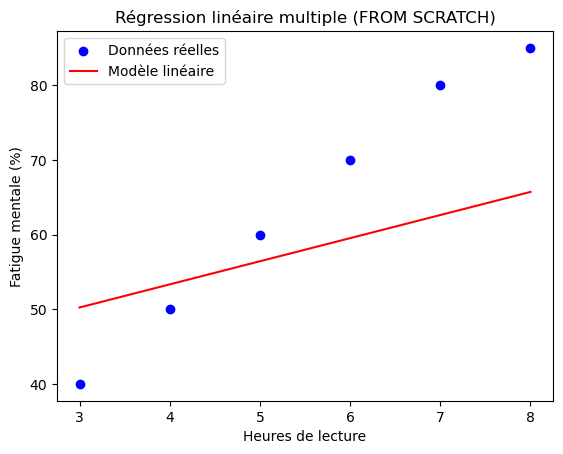

In [12]:
# Régression linéaire multiple avec SKLEARN
import numpy as np  
# On importe numpy pour manipuler facilement les données sous forme de tableaux (vecteurs et matrices)
# et effectuer des calculs numériques rapides.

import matplotlib.pyplot as plt  
# Bibliothèque utilisée pour la visualisation des données sous forme de graphiques.

from sklearn.linear_model import LinearRegression  
# Import du modèle de régression linéaire multiple déjà implémenté dans sklearn
# Ce modèle permet d'apprendre automatiquement la relation entre plusieurs variables et une cible.


# 1. Dataset
# ================================

X = np.array([
    [3, 2, 7],
    [4, 3, 6],
    [5, 4, 5],
    [6, 5, 4],
    [7, 6, 3],
    [8, 7, 2]
])
# X représente les variables explicatives (inputs) :
# - colonne 1 : heures de lecture
# - colonne 2 : temps passé sur les réseaux sociaux
# - colonne 3 : heures de sommeil
# Chaque ligne correspond à un étudiant différent

y = np.array([40, 50, 60, 70, 80, 85])  
# y représente la variable cible :
# niveau de fatigue mentale (plus la valeur est élevée, plus la fatigue est grande)


# 2. Création du modèle
# ================================

model = LinearRegression()  
# Création d'un objet modèle de régression linéaire multiple
# À ce stade, le modèle n’a encore rien appris


# 3. Entraînement
# ================================

model.fit(X, y)  
# Le modèle apprend automatiquement la relation entre X et y
# Il calcule :
# - les coefficients (importance de chaque variable)
# - l’intercept (valeur de base)
# en minimisant l’erreur globale (MSE)

# 4. Prédiction
# ================================

prediction = model.predict([[5, 3, 6]])  
# On donne une nouvelle situation :
# 5h de lecture, 3h réseaux sociaux, 6h de sommeil
# Le modèle retourne une estimation de la fatigue mentale

print("Fatigue estimée :", prediction[0])  
# Affichage du résultat final de la prédiction

# 5. Paramètres du modèle
# ================================

print("Coefficients :", model.coef_)  
# Affiche l’impact de chaque variable :
# coef[0] → lecture
# coef[1] → réseaux sociaux
# coef[2] → sommeil

print("Intercept :", model.intercept_)  
# Valeur de base du modèle lorsque toutes les variables sont égales à 0

# 6. Graphe (visualisation simplifiée)
# ====================================

# Régression multiple = 3 variables → impossible à afficher directement en 2D
# Donc on fixe 2 variables et on fait varier 1 variable (lecture)

lecture = np.linspace(3, 8, 100)  
# On génère 100 valeurs continues pour la variable "lecture"

social = 4  
# On fixe le temps passé sur les réseaux sociaux (constant)

sommeil = 6  
# On fixe les heures de sommeil (constant)

# On construit les données pour la prédiction du graphe
X_plot = np.c_[lecture,
               np.full(100, social),
               np.full(100, sommeil)]
# Chaque ligne représente :
# [lecture variable, réseaux sociaux fixes, sommeil fixe]

# On calcule les valeurs prédites par le modèle
y_plot = model.predict(X_plot)  
# On obtient la courbe de la fatigue en fonction de la lecture


# Affichage du graphe
# ================================

plt.scatter(X[:, 0], y, color='blue', label="Données réelles")
# On affiche les vraies données (lecture vs fatigue)

plt.plot(lecture, y_plot, color='red', label="Modèle linéaire")
# On trace la courbe du modèle

plt.xlabel("Heures de lecture")  
# Axe X

plt.ylabel("Fatigue mentale (%)")  
# Axe Y

plt.title("Régression linéaire multiple (FROM SCRATCH)")  
# Titre du graphe

plt.legend()  
# Afficher la légende

plt.show()  
# Afficher le graphique

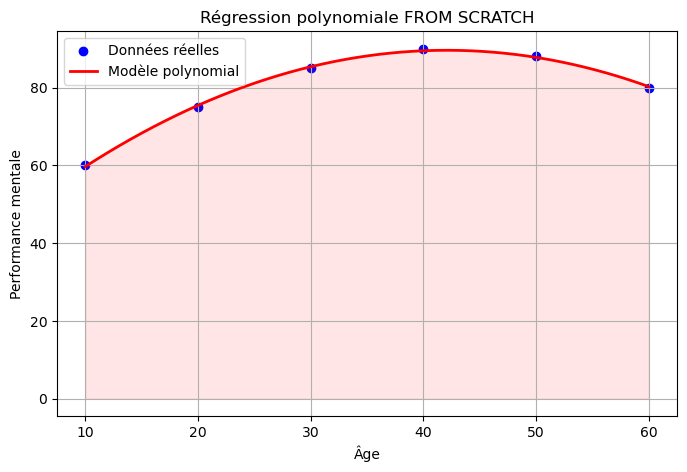

In [21]:
#Régression polynomiale FROM SCRATCH
import numpy as np
import matplotlib.pyplot as plt


# 1. Dataset
# ================================

X = np.array([10, 20, 30, 40, 50, 60], dtype=float)
# X représente la variable d’entrée (âge des personnes)
# On choisit l’âge car il influence souvent la performance cognitive

y = np.array([60, 75, 85, 90, 88, 80], dtype=float)
# y représente la variable cible (performance mentale)
# On observe ici une évolution non linéaire :
# augmentation au début puis légère diminution

m = len(X)
# m correspond au nombre total d’observations dans le dataset


# 2. Normalisation
# ================================

X_mean = np.mean(X)
# calcul de la moyenne des âges

X_std = np.std(X)
# calcul de l’écart-type pour mesurer la dispersion des valeurs

X_norm = (X - X_mean) / X_std
# normalisation des données :
# on centre et réduit X pour éviter les problèmes numériques
# et stabiliser la descente de gradient


# 3. Transformation polynomiale
# ================================

X_poly = np.c_[np.ones(m), X_norm, X_norm**2]
# transformation des données en espace polynomial :
# - 1 → permet d’ajouter l’intercept (b)
# - X_norm → relation linéaire
# - X_norm² → capture la courbure (non-linéarité)
# Cela permet au modèle de s’adapter à des relations complexes

theta = np.zeros(3)
# initialisation des paramètres du modèle à zéro :
# theta[0] = b (intercept)
# theta[1] = coefficient de X
# theta[2] = coefficient de X²


# 4. Gradient Descent
# ================================

learning_rate = 0.01
# contrôle la vitesse d’apprentissage :
# trop grand → divergence, trop petit → apprentissage lent

iterations = 3000
# nombre d’itérations pour optimiser progressivement les paramètres

for i in range(iterations):

    predictions = X_poly.dot(theta)
    # calcul des prédictions actuelles du modèle

    error = predictions - y
    # calcul de l’erreur entre prédictions et valeurs réelles
    # cette erreur guide l’amélioration du modèle

    gradients = (1/m) * X_poly.T.dot(error)
    # calcul du gradient :
    # il indique la direction dans laquelle les paramètres doivent évoluer
    # pour réduire l’erreur globale

    theta = theta - learning_rate * gradients
    # mise à jour des paramètres du modèle
    # objectif : minimiser la fonction de coût progressivement


# 5. Courbe de prédiction
# ================================

X_plot = np.linspace(10, 60, 200)
# génération de valeurs continues pour obtenir une courbe fluide

X_plot_norm = (X_plot - X_mean) / X_std
# application de la même normalisation que les données d’entraînement

X_plot_poly = np.c_[np.ones(200), X_plot_norm, X_plot_norm**2]
# transformation des données de test en espace polynomial

y_plot = X_plot_poly.dot(theta)
# calcul des prédictions du modèle pour tracer la courbe


# 6. Visualisation (graphe)
# ================================

plt.figure(figsize=(8,5))
# création d’une figure plus grande pour une meilleure lisibilité

plt.scatter(X, y, color="blue", label="Données réelles")
# affichage des points réels du dataset

plt.plot(X_plot, y_plot, color="red", linewidth=2, label="Modèle polynomial")
# affichage de la courbe apprise par le modèle

plt.fill_between(X_plot, y_plot, color="red", alpha=0.1)
# ajout d’une zone colorée pour améliorer la visualisation de la tendance

plt.xlabel("Âge")
# label de l’axe X

plt.ylabel("Performance mentale")
# label de l’axe Y

plt.title("Régression polynomiale FROM SCRATCH")
# titre du graphique

plt.legend()
# affichage de la légende

plt.grid(True)
# ajout d’une grille pour faciliter la lecture

plt.show()
# affichage final du graphique

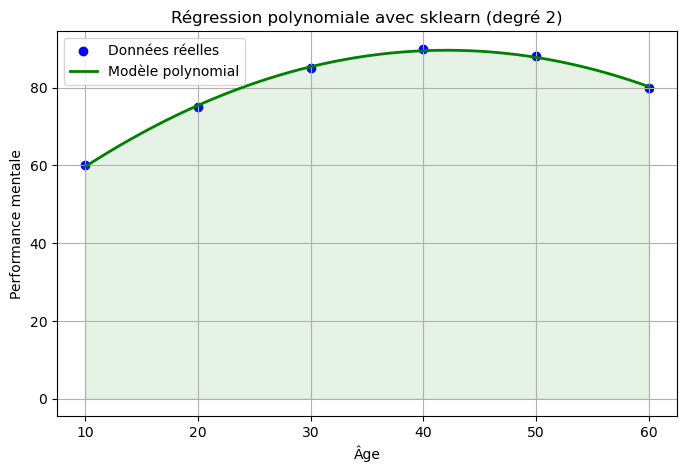

Coefficients : [ 0.          2.44892857 -0.02910714]
Intercept : 38.10000000000026


In [28]:
#Régression polynomiale avec SKLEARN
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
# modèle de régression linéaire classique utilisé après transformation des données

from sklearn.preprocessing import PolynomialFeatures
# outil qui permet de transformer les variables en polynômes (x → x², x³...)
# afin de modéliser des relations non linéaires


# 1. Dataset
# ================================

X = np.array([10, 20, 30, 40, 50, 60]).reshape(-1, 1)
# X représente la variable d’entrée (âge des personnes)
# reshape(-1,1) transforme le vecteur en matrice colonne
# car sklearn exige un format 2D pour les variables explicatives

y = np.array([60, 75, 85, 90, 88, 80])
# y représente la variable cible (performance mentale)
# on observe une relation non linéaire : augmentation puis légère baisse


# 2. Transformation polynomiale
# ================================

poly = PolynomialFeatures(degree=2)
# on définit un polynôme de degré 2 :
# cela signifie que le modèle utilisera :
# - x (variable originale)
# - x² (capturer la courbure de la relation)

X_poly = poly.fit_transform(X)
# transformation des données :
# chaque valeur de X devient [1, x, x²]
# - 1 : intercept automatique
# - x : relation linéaire
# - x² : permet de modéliser la non-linéarité


# 3. Modèle d’apprentissage
# ================================

model = LinearRegression()
# création du modèle de régression linéaire

model.fit(X_poly, y)
# entraînement du modèle :
# il apprend les coefficients optimaux pour minimiser l’erreur (MSE)
# entre les valeurs prédites et les valeurs réelles


# 4. Courbe de prédiction
# ================================

X_plot = np.linspace(10, 60, 200).reshape(-1, 1)
# génération de points continus pour obtenir une courbe fluide

X_plot_poly = poly.transform(X_plot)
# application de la même transformation polynomiale sur les nouvelles données
# pour rester cohérent avec le modèle entraîné

y_plot = model.predict(X_plot_poly)
# prédiction du modèle pour chaque point de X_plot
# cela permet de tracer la courbe apprise


# 5. Visualisation (graphe)
# ================================

plt.figure(figsize=(8,5))
# création d’une figure plus grande pour améliorer la lisibilité

plt.scatter(X, y, color="blue", label="Données réelles")
# affichage des points réels du dataset

plt.plot(X_plot, y_plot, color="green", linewidth=2, label="Modèle polynomial")
# affichage de la courbe apprise par le modèle

plt.fill_between(X_plot.flatten(), y_plot, color="green", alpha=0.1)
# ajout d’une zone colorée sous la courbe pour améliorer la visualisation

plt.xlabel("Âge")
# label de l’axe horizontal

plt.ylabel("Performance mentale")
# label de l’axe vertical

plt.title("Régression polynomiale avec sklearn (degré 2)")
# titre du graphique

plt.legend()
# affichage de la légende

plt.grid(True)
# ajout d’une grille pour faciliter la lecture

plt.show()
# affichage final du graphique


# 6. Paramètres du modèle
# ================================

print("Coefficients :", model.coef_)
# coefficients appris par le modèle :
# ils indiquent l’impact de chaque variable (x et x²)

print("Intercept :", model.intercept_)
# constante du modèle (b)
# valeur de base lorsque toutes les variables sont nulles

Probabilité (score=6): 0.5


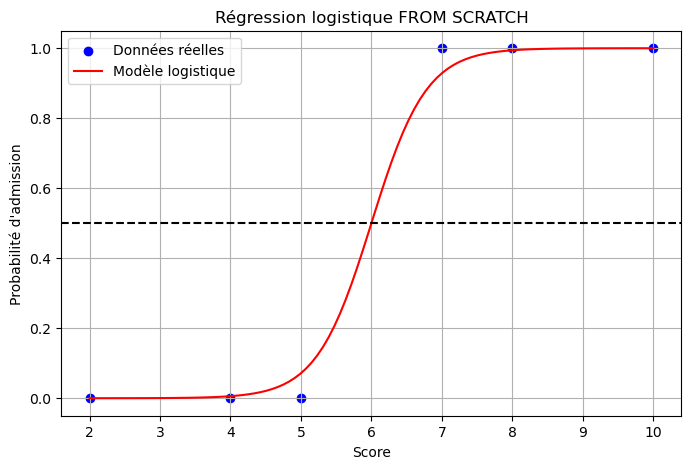

In [29]:
#regression logistique from scratch
import numpy as np
import matplotlib.pyplot as plt


# 1. Dataset
# ================================

X = np.array([2, 4, 5, 7, 8, 10])  
# X représente la variable d’entrée (score des étudiants)
# cette variable influence directement la probabilité de réussite

y = np.array([0, 0, 0, 1, 1, 1])  
# y est la variable cible (classification binaire)
# 0 → étudiant non admis
# 1 → étudiant admis

m = len(X)  
# m représente le nombre total d’observations dans le dataset

# 2. Normalisation des données
# ================================

X_mean = np.mean(X)  
# calcul de la moyenne des scores

X_std = np.std(X)  
# calcul de l’écart-type (mesure de dispersion)

X_norm = (X - X_mean) / X_std  
# normalisation des données :
# on centre et réduit X pour éviter les problèmes numériques
# et améliorer la stabilité de la descente de gradient

X_b = np.c_[np.ones(m), X_norm]  
# ajout d’une colonne de 1 :
# cela permet d’intégrer l’intercept (b) dans le modèle

# 3. Fonction Sigmoid
# ================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# la fonction sigmoid transforme une valeur réelle en probabilité entre 0 et 1
# elle permet de convertir le résultat du modèle en probabilité d’appartenance à une classe

# 4. Initialisation des paramètres
# ================================

theta = np.zeros(2)  
# initialisation des paramètres du modèle :
# theta[0] = intercept (b)
# theta[1] = coefficient de X

learning_rate = 0.1  
# contrôle la vitesse d’apprentissage :
# trop grand → instabilité
# trop petit → apprentissage lent

iterations = 2000  
# nombre d’itérations pour optimiser les paramètres

# 5. Gradient Descent
# ================================

for i in range(iterations):

    z = X_b.dot(theta)  
    # combinaison linéaire des variables :
    # z = b + a*x

    predictions = sigmoid(z)  
    # transformation de z en probabilité (0 à 1)

    error = predictions - y  
    # calcul de l’erreur entre prédictions et valeurs réelles

    gradients = (1/m) * X_b.T.dot(error)  
    # calcul du gradient :
    # il indique comment modifier les paramètres pour réduire l’erreur

    theta = theta - learning_rate * gradients  
    # mise à jour des paramètres pour améliorer le modèle progressivement

# 6. Fonction de prédiction
# ================================

def predict(x):
    x_norm = (x - X_mean) / X_std  
    # on applique la même normalisation que durant l’entraînement

    x_b = np.array([1, x_norm])  
    # ajout de l’intercept

    prob = sigmoid(x_b.dot(theta))  
    # calcul de la probabilité d’admission

    return prob

print("Probabilité (score=6):", predict(6))
# affiche la probabilité qu’un étudiant avec score 6 soit admis

# 7. Visualisation (graphe)
# ================================

X_plot = np.linspace(2, 10, 100)  
# génération de valeurs continues pour tracer une courbe fluide

X_plot_norm = (X_plot - X_mean) / X_std  
# normalisation des valeurs de test

X_plot_b = np.c_[np.ones(100), X_plot_norm]  
# ajout de l’intercept pour chaque point

y_plot = sigmoid(X_plot_b.dot(theta))  
# calcul des probabilités pour chaque point

plt.figure(figsize=(8,5))

plt.scatter(X, y, color="blue", label="Données réelles")
# affichage des données originales (classes réelles)

plt.plot(X_plot, y_plot, color="red", label="Modèle logistique")
# courbe sigmoïde apprise par le modèle

plt.axhline(0.5, color="black", linestyle="--")
# seuil de décision :
# si prob > 0.5 → classe 1
# sinon → classe 0

plt.xlabel("Score")
plt.ylabel("Probabilité d'admission")
plt.title("Régression logistique FROM SCRATCH")
plt.legend()
plt.grid(True)

plt.show()

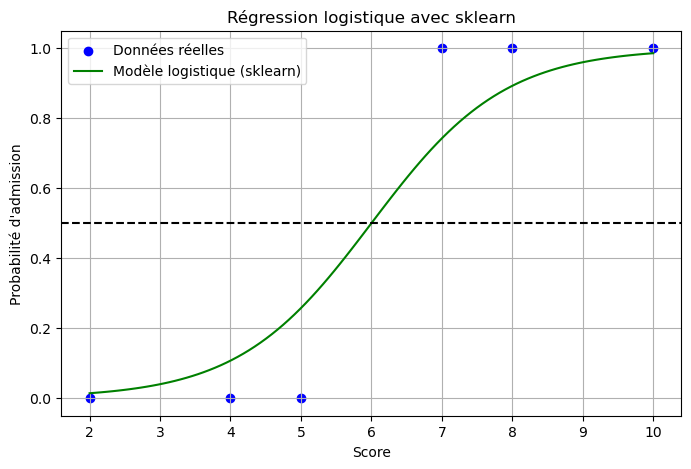

Coefficient : [[1.05883693]]
Intercept : [-6.35305117]


In [30]:
#regression logistique avec sklearn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
# modèle de régression logistique déjà optimisé dans sklearn
# il permet de faire de la classification binaire (0 / 1)


# 1. Dataset
# ================================

X = np.array([2, 4, 5, 7, 8, 10]).reshape(-1, 1)
# X représente la variable d’entrée (score des étudiants)
# reshape(-1,1) transforme le vecteur en matrice colonne
# car sklearn exige un format 2D pour les features

y = np.array([0, 0, 0, 1, 1, 1])
# y représente la variable cible (classification binaire)
# 0 = non admis
# 1 = admis


# 2. Création du modèle
# ================================

model = LogisticRegression()
# création du modèle de régression logistique
# ce modèle apprend une frontière de décision basée sur une fonction sigmoïde

model.fit(X, y)
# entraînement du modèle :
# sklearn ajuste automatiquement les paramètres (poids + intercept)
# en utilisant une optimisation interne (liblinear / lbfgs)

# 3. Courbe de probabilité
# ================================

X_plot = np.linspace(2, 10, 100).reshape(-1, 1)
# génération de valeurs continues pour tracer une courbe fluide

y_plot = model.predict_proba(X_plot)[:, 1]
# predict_proba retourne les probabilités pour chaque classe :
# [:,1] → probabilité d’appartenir à la classe 1 (admis)
# cela permet de tracer la courbe sigmoïde


# 4. Visualisation
# ================================

plt.figure(figsize=(8,5))
# création d’une figure plus grande pour améliorer la lisibilité

plt.scatter(X, y, color="blue", label="Données réelles")
# affichage des points réels du dataset (classes 0 et 1)

plt.plot(X_plot, y_plot, color="green", label="Modèle logistique (sklearn)")
# courbe sigmoïde apprise par le modèle

plt.axhline(0.5, color="black", linestyle="--")
# seuil de décision :
# si probabilité > 0.5 → classe 1 (admis)
# sinon → classe 0 (non admis)

plt.xlabel("Score")
# label de l’axe X

plt.ylabel("Probabilité d'admission")
# label de l’axe Y

plt.title("Régression logistique avec sklearn")
# titre du graphique

plt.legend()
# affichage de la légende

plt.grid(True)
# ajout d’une grille pour faciliter la lecture

plt.show()
# affichage final du graphique

# 5. Paramètres appris
# ================================

print("Coefficient :", model.coef_)
# coefficient appris :
# il indique l’impact du score sur la probabilité d’admission

print("Intercept :", model.intercept_)
# intercept (biais) :
# valeur de base du modèle lorsque X = 0